In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("../data/Algerian_forest_fires_dataset.csv")
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [3]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [5]:
df.drop(["day", "month", "year"], axis=1, inplace=True)
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [6]:
df["Classes"].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [7]:
# Encoding 
df['Classes'] = df['Classes'].str.strip().str.lower()

df['Classes'] = df['Classes'].map({
    'not fire': 0,
    'fire': 1
})

In [8]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [9]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [10]:
## Independent and dependent features

X = df.drop('FWI', axis=1)
y = df['FWI']

In [11]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [12]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

In [13]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [14]:
X_train.shape, X_test.shape

((182, 11), (61, 11))

In [16]:
## Feature Selection based on Correlation

X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


<Axes: >

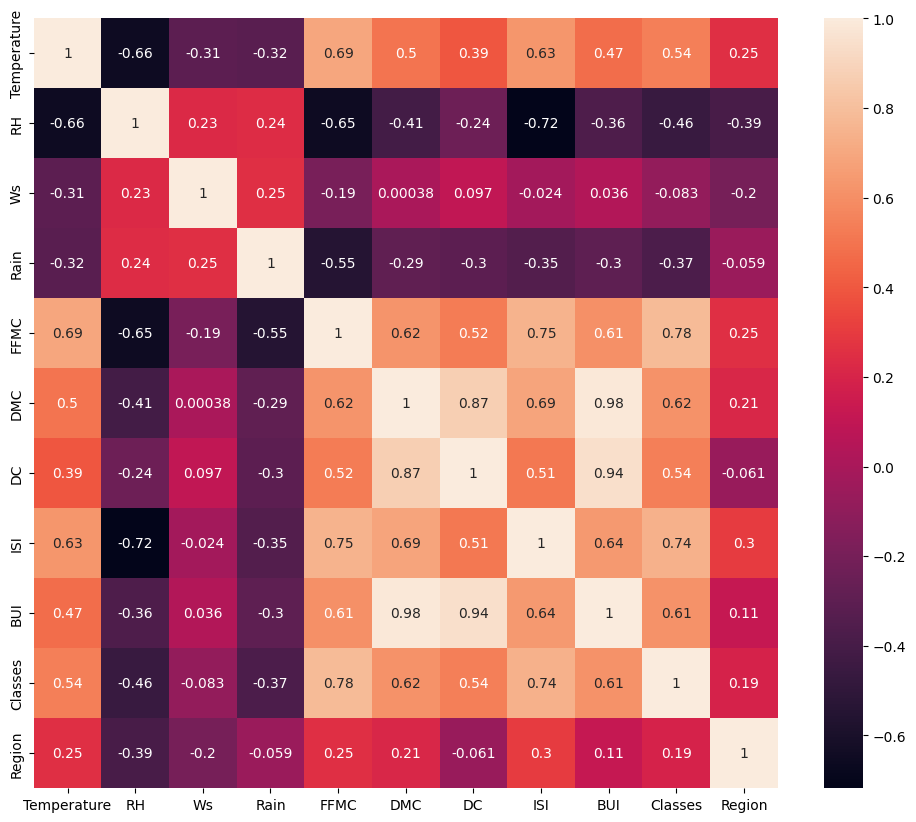

In [17]:
## Check for multicollinearity
plt.figure(figsize=(12,10))
corr = X_train.corr()
sns.heatmap(corr, annot=True)

In [20]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [23]:
## threshold -- Domain expertise
corr_features = correlation(X_train, 0.75)

In [24]:
## drop features when correlation is more 0.85
X_train.drop(corr_features, axis=1, inplace=True)
X_test.drop(corr_features, axis=1, inplace=True)
X_train.shape, X_test.shape

((182, 7), (61, 7))

2 features droped  with this particular treshold

## Feature Scaling or Standardization

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
X_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.12805583,
        -0.88272888, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -1.21758569,
        -0.86687565,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  1.15703067,
         0.61540157,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -2.20933724,
        -1.06504105, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.73099656,
         0.37760309,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -1.33631651,
        -1.01748135, -0.98907071]], shape=(182, 7))

## Box Plots to understand Effect of Standard Scaler

Text(0.5, 1.0, 'X_train After Scaling')

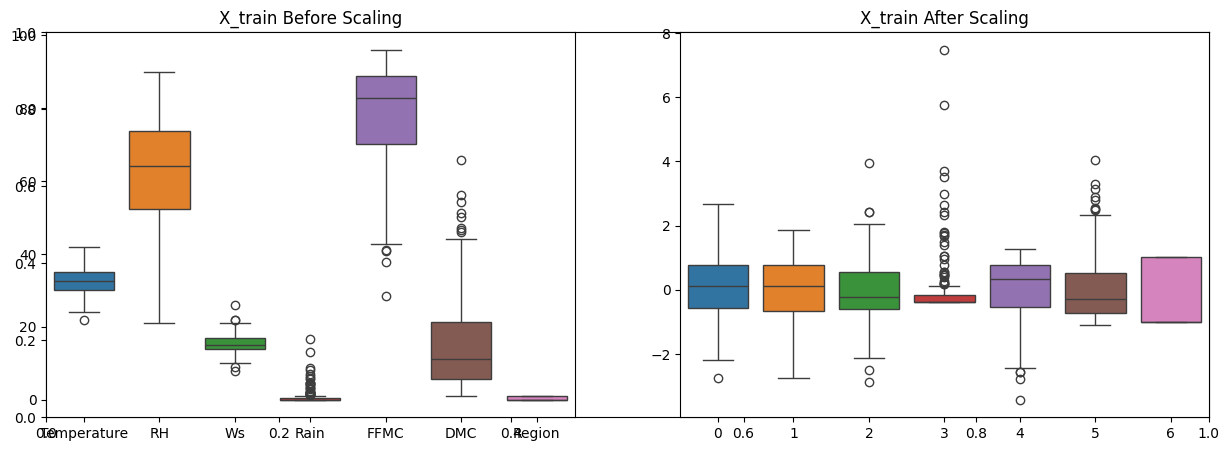

In [27]:
plt.subplots(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title('X_train Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train After Scaling')

### Linear Regression Model

Mean absolute error 2.2301202183547093
R2 Score 0.7982160136811767


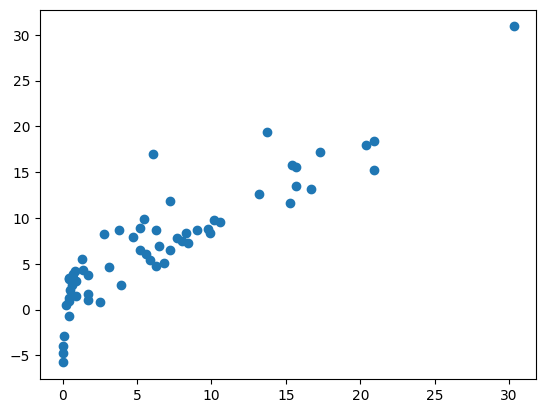

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


ligreg = LinearRegression()
ligreg.fit(X_train_scaled, y_train)
y_pred = ligreg.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test, y_pred)

## Lasso Regression

Mean absolute error 2.4580026414262974
R2 Score 0.7748202345729962


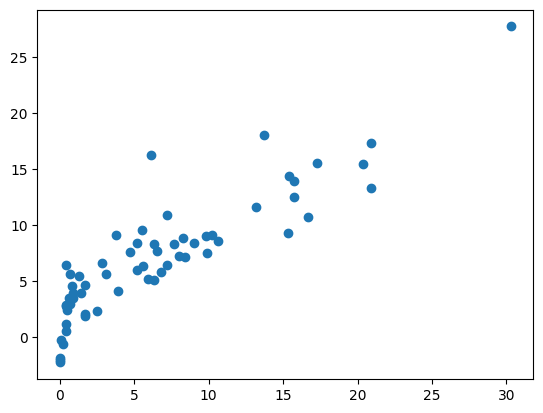

In [31]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score


lasso = Lasso()
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test, y_pred)

## Ridge Regression Model

Mean absolute error 2.228453700705173
R2 Score 0.7985255932362753


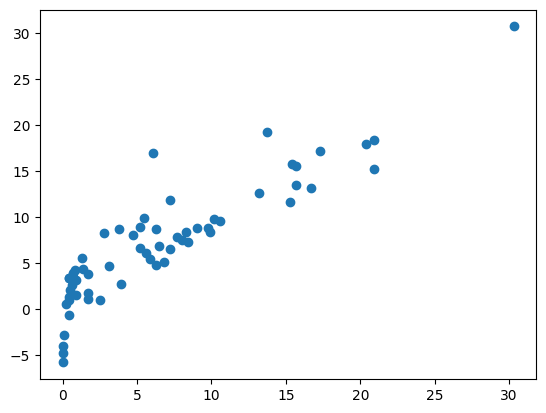

In [32]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score


ridge = Ridge()
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test, y_pred)

Ridge regression slightly outperformed standard linear regression, indicating mild multicollinearity while preserving all features. Lasso underperformed, suggesting that feature elimination was not beneficial for this dataset.

## ElasticNet Regression

Mean absolute error 2.8281228552037083
R2 Score 0.7240370520781505


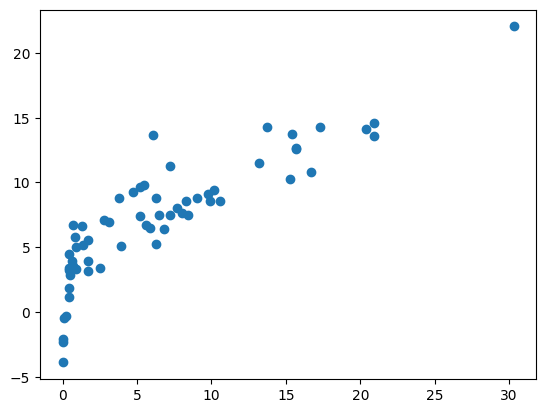

In [33]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, r2_score


elastic = ElasticNet()
elastic.fit(X_train_scaled, y_train)
y_pred = elastic.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test, y_pred)

## Cross Validation Lasso

In [34]:
from sklearn.linear_model import LassoCV

lassocv = LassoCV(cv=5)
lassocv.fit(X_train, y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [35]:
lassocv.predict(X_test_scaled)

c:\Users\eliza\VSCode\ml-practice\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LassoCV was fitted with feature names
  warnings.warn(


array([ 0.88047292,  0.68644215,  0.67279653,  0.90673674,  0.85480815,
        0.30967205,  0.50921223,  1.09908542,  0.31892607,  1.12471541,
        0.90050649,  1.60598776,  0.91847159,  1.70522061,  1.82821131,
        0.8137241 ,  0.17359395, -0.12599441,  0.67336985,  0.47296052,
        0.55195798,  0.33046409,  0.65557486,  0.61769654,  1.45573298,
        0.79664576,  0.73361724,  1.05097015, -0.01663941,  1.13183139,
        0.88654856,  0.28236804,  1.21543268,  1.61754205,  0.67336328,
        0.52517543,  0.46935837,  0.96945099,  0.16917559,  1.13795511,
        0.84200753,  0.38490476,  0.75409176,  0.07350847,  1.23807275,
        0.95157198,  1.09876373,  0.46547779,  1.35154573,  0.78216971,
        2.78376579,  0.86972809,  1.64873863,  1.69890253,  1.36858756,
        2.02083084,  0.65707554,  1.06563265,  0.53179167,  1.40916449,
        0.93205363])

In [36]:
lassocv.alpha_

np.float64(0.4536678200381513)

In [37]:
lassocv.mse_path_

array([[50.8129891 , 65.39074075, 52.50462315, 77.90299066, 41.59867037],
       [46.42020879, 61.07250415, 47.76817751, 77.90299066, 36.54285826],
       [42.55461285, 55.23199904, 43.60446554, 72.6661576 , 32.24150621],
       [39.15056645, 50.12622899, 39.94186658, 64.92279464, 28.58987932],
       [36.15077949, 45.53767845, 36.71788789, 58.23839866, 25.49732026],
       [33.50523339, 41.49780477, 33.87798925, 52.44277438, 22.74931213],
       [30.88393886, 37.95124576, 31.3745598 , 47.41894926, 20.38658726],
       [28.47331329, 34.776878  , 28.99039636, 43.06526581, 18.3819368 ],
       [26.35580263, 31.82559345, 26.51277068, 39.29335093, 16.68534959],
       [24.19541834, 29.23284706, 24.29970197, 35.99590606, 15.25346872],
       [22.27165308, 26.95328767, 22.07371209, 32.80776681, 13.94584687],
       [20.58874071, 24.94796828, 20.12723364, 30.04592021, 12.84215529],
       [19.11596832, 23.18269709, 18.42462801, 27.65417866, 11.92039908],
       [17.82657564, 21.62763281, 16.9

c:\Users\eliza\VSCode\ml-practice\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LassoCV was fitted with feature names
  warnings.warn(


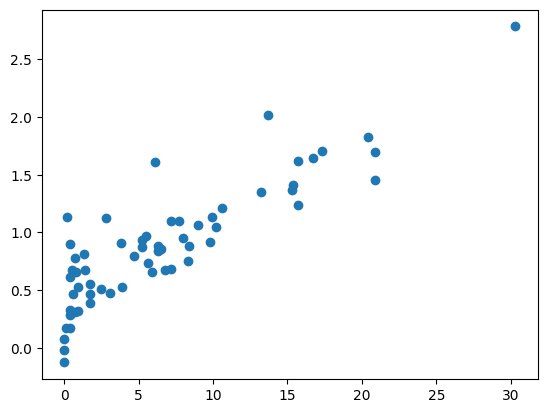

In [38]:
y_pred = lassocv.predict(X_test_scaled)
plt.scatter(y_test, y_pred)

Mean absolute error 2.228453700705173
R2 Score 0.7985255932362753


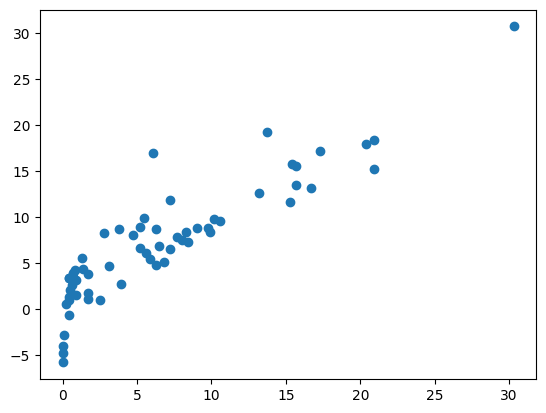

In [ ]:
from sklearn.linear_model import RidgeCV

ridgecv = RidgeCV(v=5)
ridgecv.fit(X_train_scaled, y_train)
y_pred = ridgecv.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test, y_pred)

In [41]:
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': False}